# 02 - Tiền xử lý và phân tích dữ liệu đánh giá FPTShop Laptop
Notebook này tập trung làm sạch dữ liệu và phân tích mô tả, không sử dụng Machine Learning.

In [ ]:
%pip install pandas matplotlib seaborn

In [1]:
import os
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
os.makedirs("outputs", exist_ok=True)

raw_path = "data/fptshop_laptop_raw.csv"
df = pd.read_csv(raw_path)

required_columns = [
    "review_id",
    "item_id",
    "user_id",
    "rating_star",
    "comment",
    "created_at",
    "like_count",
    "source"
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Thiếu cột bắt buộc trong dữ liệu thô: {missing_columns}")

print(f"Số dòng dữ liệu thô: {len(df)}")
display(df.head())

Số dòng dữ liệu thô: 852


,review_id,shop_id,item_id,user_id,rating_star,comment,created_at,like_count,product_items,source
0,Anh KhoiPD DX_201234,FPTShop,925801,Anh KhoiPD DX,4.0,Máy dùng tốt,NaN,0,NaN,FPTShop
1,chi mai_199345,FPTShop,925128,chi mai,5.0,siêu dth,NaN,0,NaN,FPTShop
2,Trần Minh Huy_185078,FPTShop,922302,Trần Minh Huy,5.0,"Con máy này chạy mượt mà cực kỳ, chơi game hay...",NaN,0,NaN,FPTShop
3,Phan Văn Hải_184943,FPTShop,922302,Phan Văn Hải,4.0,"E này thiết kế đẹp mắt lắm mọi người ạ, màu đe...",NaN,0,NaN,FPTShop
4,Huỳnh Thảo Vy_183464,FPTShop,922302,Huỳnh Thảo Vy,4.0,"Con máy đáng đồng tiền bát gạo, mọi người cứ y...",NaN,0,NaN,FPTShop


In [3]:
def normalize_text(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["comment"] = df["comment"].fillna("").astype(str)
df["comment_clean"] = df["comment"].apply(normalize_text)
df = df[df["comment_clean"].str.len() > 0].copy()
df = df.drop_duplicates(subset=["review_id", "comment_clean"]).reset_index(drop=True)

df["rating_star"] = pd.to_numeric(df["rating_star"], errors="coerce")
df = df[df["rating_star"].between(1, 5, inclusive="both")].copy()
df["review_len"] = df["comment_clean"].str.len()
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

print(f"Số dòng sau làm sạch: {len(df)}")
display(df.head())

Số dòng sau làm sạch: 810


,review_id,shop_id,item_id,user_id,rating_star,comment,created_at,like_count,product_items,source,comment_clean,review_len
0,Anh KhoiPD DX_201234,FPTShop,925801,Anh KhoiPD DX,4.0,Máy dùng tốt,NaT,0,NaN,FPTShop,máy dùng tốt,12
1,chi mai_199345,FPTShop,925128,chi mai,5.0,siêu dth,NaT,0,NaN,FPTShop,siêu dth,8
2,Trần Minh Huy_185078,FPTShop,922302,Trần Minh Huy,5.0,"Con máy này chạy mượt mà cực kỳ, chơi game hay...",NaT,0,NaN,FPTShop,con máy này chạy mượt mà cực kỳ chơi game hay ...,91
3,Phan Văn Hải_184943,FPTShop,922302,Phan Văn Hải,4.0,"E này thiết kế đẹp mắt lắm mọi người ạ, màu đe...",NaT,0,NaN,FPTShop,e này thiết kế đẹp mắt lắm mọi người ạ màu đen...,91
4,Huỳnh Thảo Vy_183464,FPTShop,922302,Huỳnh Thảo Vy,4.0,"Con máy đáng đồng tiền bát gạo, mọi người cứ y...",NaT,0,NaN,FPTShop,con máy đáng đồng tiền bát gạo mọi người cứ yê...,59


In [4]:
summary = pd.DataFrame({
    "metric": [
        "count_reviews",
        "min_rating",
        "max_rating",
        "avg_rating",
        "median_rating",
        "avg_review_len",
        "min_review_len",
        "max_review_len"
    ],
    "value": [
        len(df),
        df["rating_star"].min(),
        df["rating_star"].max(),
        round(df["rating_star"].mean(), 4),
        df["rating_star"].median(),
        round(df["review_len"].mean(), 2),
        df["review_len"].min(),
        df["review_len"].max()
    ]
})

display(summary)
summary.to_csv("outputs/eda_summary.csv", index=False, encoding="utf-8-sig")

,metric,value
0,count_reviews,810.0000
1,min_rating,1.0000
2,max_rating,5.0000
3,avg_rating,4.8086
4,median_rating,5.0000
5,avg_review_len,117.7600
6,min_review_len,3.0000
7,max_review_len,400.0000


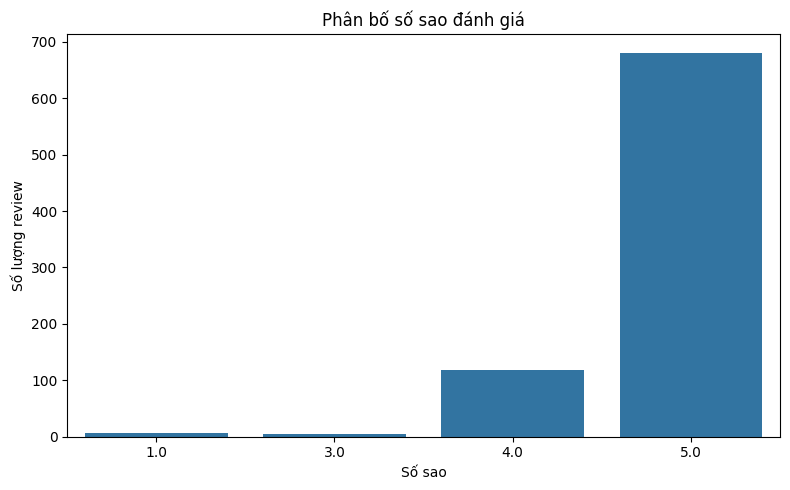

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rating_star", color="#1f77b4")
plt.title("Phân bố số sao đánh giá")
plt.xlabel("Số sao")
plt.ylabel("Số lượng review")
plt.tight_layout()
plt.savefig("outputs/chart_rating_distribution.png", dpi=150)
plt.show()

In [6]:
if df["created_at"].notna().any():
    df_time = df.dropna(subset=["created_at"]).copy()
    df_time["month"] = df_time["created_at"].dt.to_period("M").astype(str)
    monthly_count = df_time.groupby("month").size().reset_index(name="review_count")

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly_count, x="month", y="review_count", marker="o", color="#ff7f0e")
    plt.title("Xu hướng số lượng review theo tháng")
    plt.xlabel("Tháng")
    plt.ylabel("Số lượng review")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("outputs/chart_monthly_trend.png", dpi=150)
    plt.show()

    monthly_count.to_csv("outputs/table_monthly_trend.csv", index=False, encoding="utf-8-sig")
else:
    print("Không đủ dữ liệu thời gian để vẽ xu hướng theo tháng.")

Không đủ dữ liệu thời gian để vẽ xu hướng theo tháng.


In [7]:
stopwords_vi = {
    "và", "là", "của", "cho", "rất", "nhưng", "được", "mình", "shop", "sản", "phẩm",
    "này", "khi", "thì", "với", "có", "không", "đã", "trong", "hơi", "vẫn"
}

tokens = []
for text in df["comment_clean"]:
    words = [w for w in text.split() if len(w) >= 3 and w not in stopwords_vi]
    tokens.extend(words)

top_terms = pd.DataFrame(Counter(tokens).most_common(30), columns=["term", "frequency"])
display(top_terms.head(15))
top_terms.to_csv("outputs/table_top_terms.csv", index=False, encoding="utf-8-sig")

,term,frequency
0,máy,418
1,hình,204
2,mua,190
3,nhanh,186
4,dùng,171
5,tốt,171
6,làm,164
7,màn,157
8,nên,155
9,viên,151


In [8]:
rating_table = df.groupby("rating_star").size().reset_index(name="review_count").sort_values("rating_star")
display(rating_table)
rating_table.to_csv("outputs/table_rating_distribution.csv", index=False, encoding="utf-8-sig")

clean_path = "data/cleaned_reviews.csv"
df.to_csv(clean_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu dữ liệu sạch vào: {clean_path}")

,rating_star,review_count
0,1.0,7
1,3.0,4
2,4.0,119
3,5.0,680


Đã lưu dữ liệu sạch vào: data/cleaned_reviews.csv
